**Link al repositorio de GitHub:** [https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo](https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo)

# CC3104 - Aprendizaje por Refuerzo
## Laboratorio 1 - Entrega Final

---

### Task 1: Diseño formal del MDP

#### 1. Espacio de estados $\mathcal{S}$
Para que la propiedad de Markov se satisfaga razonablemente, el estado debe contener la información mínima necesaria para decidir la siguiente acción sin depender del historial pasado. El estado $S_t$ se compondrá de la tupla: $(x, y, P, B)$
*   **$(x, y)$ Posición actual:** Coordenadas en la cuadrícula 5x5. *Justificación:* Indispensable para saber dónde está el drone espacialmente.
*   **$P$ Estado del paquete:** Booleano (1 = a bordo, 0 = entregado). *Justificación:* Determina si la meta actual es dirigirse al punto de entrega o regresar a la base central.
*   **$B$ Nivel de batería:** Discretizado (ej. 0 a 100%). *Justificación:* Crítico para tomar decisiones de retorno de emergencia y evitar caídas.
*   **Omisiones deliberadas:** Velocidad del viento, temperatura de los motores, obstáculos dinámicos temporales. *Consecuencia:* Al omitirlos, la propiedad de Markov se debilita levemente porque el éxito de un movimiento dependerá de factores climáticos invisibles para el estado, introduciendo aleatoriedad estocástica en las transiciones en lugar de determinismo.

#### 2. Espacio de acciones $\mathcal{A}$
El espacio de acciones es **discreto**, ya que el entorno es una cuadrícula finita. 
*   $\mathcal{A} = \{\text{Norte, Sur, Este, Oeste}\}$ (simplificado para la simulación de navegación).
*   **Restricciones:** En los límites del grid (ej. en el borde superior), la acción de moverse fuera de la cuadrícula debería estar restringida.
*   **Modelado en MDP:** Estas restricciones se modelan mediante la **función de transición**. Si el drone intenta moverse contra una pared, la función de transición lo deja en el mismo estado con probabilidad 1.

#### 3. Función de recompensa $R(s, a, s')$
El diseño debe balancear entrega, batería y seguridad:
*   **Eficiencia:** $-1$ por cada paso (incentiva la ruta más corta).
*   **Entrega:** $+100$ por llegar a la celda de destino.
*   **Seguridad / Batería:** Penalizaciones severas por quedarse sin batería (esto lo modelaremos en la teoría, aunque para el Task 3 evaluaremos la versión de navegación espacial simplificada).
*   **Ponderación:** La seguridad tiene el peso negativo más grande absoluto. Un dron estrellado cuesta muchísimo dinero.
*   **Consecuencias de mala ponderación:** Si la penalización por paso ($-1$) fuera masiva (ej. $-200$), el dron aprendería que lo mejor es quedarse en la base sin salir para evitar acumular castigos rápidos.

#### 4. Función de transición $P(s' | s, a)$
La función debe ser **estocástica**. Aunque un drone reciba el comando "Norte", en el dominio real existen fuentes de aleatoriedad como ráfagas de viento o pérdida momentánea de señal GPS.
*   **Transición 1 (Éxito esperado):** Probabilidad $0.8$ de avanzar a la celda deseada. Las condiciones son ideales la mayor parte del tiempo.
*   **Transición 2 (Desvío por viento lateral):** Probabilidad $0.1$ de desviarse 90 grados a la derecha de la ruta deseada.
*   **Transición 3 (Freno por viento en contra):** Probabilidad $0.1$ de quedarse en la misma celda intentando avanzar sin lograr salir.

#### 5. Factor de descuento $\gamma$
Se propone **$\gamma = 0.99$**.
*   **Justificación:** En la logística urbana, cumplir el objetivo a largo plazo (entregar el paquete) es lo primordial. Un $\gamma$ muy cercano a 1 permite que la recompensa lejana de $+100$ se propague fuertemente hacia los estados iniciales. Si usaramos un $\gamma=0.5$ (miope), el drone solo vería los costos inmediatos de dar un paso y las recompensas lejanas tendrían un valor percibido cercano a cero.

---

### Task 2: Preguntas Teóricas

#### 1. Violaciones a la propiedad de Markov
*   **Situación 1 (Tráfico aéreo dinámico / Otros drones):** Si hay otros drones moviéndose, nuestro estado actual $(x,y)$ no basta para predecir colisiones, ya que las posiciones futuras dependen de las trayectorias de los demás. 
    *   *Extensión:* Incluir la posición de los demás drones en el estado.
    *   *Costo Computacional:* El espacio de estados sufriría una inmensa explosión combinatoria.
*   **Situación 2 (Degradación térmica de la batería):** Si la batería se calienta por uso prolongado, su tasa de descarga real aumenta. Conocer solo el nivel (ej. 50%) no es suficiente; importa *cómo* llegó a 50%.
    *   *Extensión:* Añadir una variable que represente la "Temperatura de motores" o "Tiempo continuo de vuelo".
    *   *Costo Computacional:* Multiplica todo el espacio de estados existente por el rango de valores de temperatura, aumentando exponencialmente los requerimientos de memoria.

#### 2. Supuesto de observabilidad completa (MDP vs POMDP)
*   **Razonabilidad:** Es poco razonable asumir observabilidad completa. Variables reales como micro-corrientes de viento locales no son observables.
*   **Impacto de usar MDP vs POMDP:** Al usar un modelo MDP estándar, estas variables ocultas se absorben ingenuamente como simple "ruido aleatorio" en la función estocástica. Esto hace que el agente no pueda razonar sobre la incertidumbre. Un modelo **POMDP** permitiría al drone mantener una *creencia* sobre variables ocultas (inferiendo el viento), siendo mucho más robusto, pero astronómicamente más difícil de calcular.

#### 3. Tarea Episódica vs Continua
*   **Clasificación:** El problema debe modelarse como una **tarea episódica**.
*   **Argumento:** Existe un final natural de la misión: el drone entrega el paquete y regresa a su base.
*   **Efecto en el diseño:** Al ser episódico, podemos usar recompensas terminales acumulativas (+100 al final). Además, podemos usar $\gamma = 1$ matemáticamente sin que la suma diverja al infinito, aunque usamos 0.99 para dar urgencia.


---
### Task 3: Implementación del Evaluador Iterativo de Políticas

Para visualizar y simular el modelo de forma manejable, implementaremos el GridWorld 5x5 proyectando el estado a puramente espacial $(x, y)$. Asumimos que el objetivo terminal es la esquina inferior derecha $(4, 4)$ con recompensa $+100$.


Evaluando Política Uniforme Aleatoria...
Convergencia en 353 iteraciones.


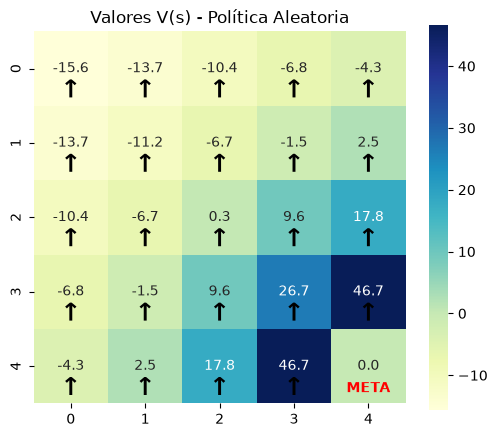


Evaluando Política Determinista Fija (Manual)...
Convergencia en 30 iteraciones.


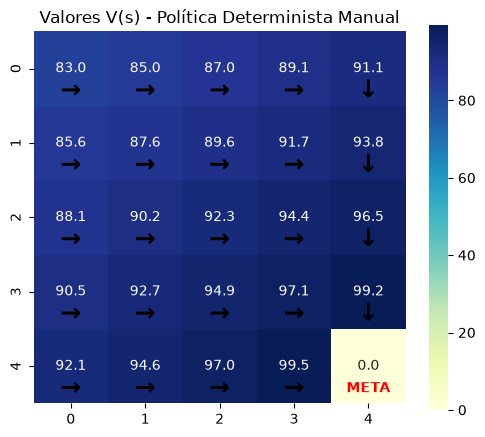


Derivando Política Greedy de la Aleatoria y Evaluándola...
Convergencia en 30 iteraciones.


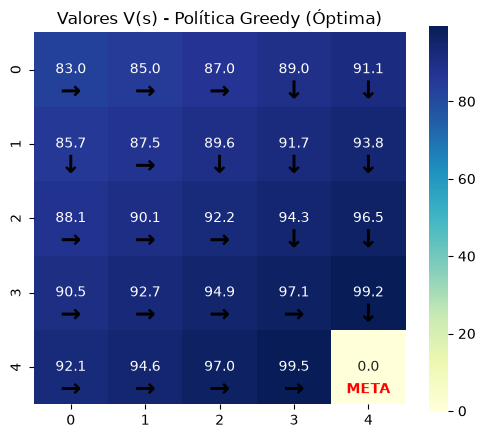

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Definición del MDP Completo
# ---------------------------------------------------------
GRID_SIZE = 5
DESTINO = (4, 4)
GAMMA = 0.99
THETA = 1e-5

# Acciones: 0=Norte, 1=Este, 2=Sur, 3=Oeste
ACTIONS = [0, 1, 2, 3]
ACTION_ARROWS = {0: '↑', 1: '→', 2: '↓', 3: '←'}

# Desplazamientos espaciales (dy, dx)
DELTAS = {
    0: (-1, 0), # Norte
    1: (0, 1),  # Este
    2: (1, 0),  # Sur
    3: (0, -1)  # Oeste
}

def get_next_state(s, a):
    """Calcula el siguiente estado dada una acción (determinista). Maneja colisiones con bordes."""
    if s == DESTINO:
        return s
    r, c = s
    dr, dc = DELTAS[a]
    nr, nc = r + dr, c + dc
    # Restricción de límites: si choca, se queda en el mismo estado
    if nr < 0 or nr >= GRID_SIZE or nc < 0 or nc >= GRID_SIZE:
        return s
    return (nr, nc)

def transition_probabilities(s, a):
    """
    Función de transición estocástica P(s' | s, a) definida en la Tarea 1:
    0.8 éxito, 0.1 desvío lateral derecho, 0.1 viento en contra (se queda en el mismo lugar).
    Devuelve lista de (probabilidad, estado_siguiente, recompensa)
    """
    if s == DESTINO:
        return [(1.0, s, 0)] # Estado terminal
        
    transitions = []
    
    # 1. Éxito esperado (0.8)
    s_exito = get_next_state(s, a)
    r_exito = 100 if s_exito == DESTINO else -1
    transitions.append((0.8, s_exito, r_exito))
    
    # 2. Desvío lateral derecho (0.1) -> La acción + 1 mod 4
    a_desvio = (a + 1) % 4
    s_desvio = get_next_state(s, a_desvio)
    r_desvio = 100 if s_desvio == DESTINO else -1
    transitions.append((0.1, s_desvio, r_desvio))
    
    # 3. Viento en contra / se queda (0.1)
    transitions.append((0.1, s, -1))
    
    return transitions

# ---------------------------------------------------------
# 2. Algoritmo de Evaluación Iterativa de Políticas
# ---------------------------------------------------------
def evaluate_policy(policy, gamma=GAMMA, theta=THETA):
    """
    Evalúa una política dada usando el operador de Bellman hasta convergencia.
    policy: dict que mapea estado -> lista de probabilidades por acción
    """
    V = np.zeros((GRID_SIZE, GRID_SIZE))
    iterations = 0
    
    while True:
        delta = 0
        V_new = np.copy(V)
        
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                s = (r, c)
                if s == DESTINO:
                    continue # El valor del estado terminal es 0
                
                v_val = 0
                for a in ACTIONS:
                    prob_a = policy[s][a]
                    if prob_a == 0:
                        continue
                    
                    # Esperanza sobre transiciones
                    for prob_s_prime, s_prime, reward in transition_probabilities(s, a):
                        v_val += prob_a * prob_s_prime * (reward + gamma * V[s_prime[0], s_prime[1]])
                        
                V_new[r, c] = v_val
                delta = max(delta, abs(v_val - V[r, c]))
                
        V = V_new
        iterations += 1
        if delta < theta:
            break
            
    return V, iterations

def get_greedy_policy(V, gamma=GAMMA):
    """
    Deriva la política greedy (determinista) a partir de los valores de estado V.
    """
    policy = {}
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            s = (r, c)
            action_values = []
            for a in ACTIONS:
                q_val = 0
                for prob_s_prime, s_prime, reward in transition_probabilities(s, a):
                    q_val += prob_s_prime * (reward + gamma * V[s_prime[0], s_prime[1]])
                action_values.append(q_val)
                
            best_a = np.argmax(action_values)
            # Crear distribución determinista para la mejor acción
            policy[s] = [1.0 if a == best_a else 0.0 for a in ACTIONS]
    return policy

# ---------------------------------------------------------
# 3. Visualización
# ---------------------------------------------------------
def plot_values_and_policy(V, policy, title):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(V, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True, square=True)
    
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) == DESTINO:
                ax.text(c+0.5, r+0.8, 'META', ha='center', va='center', color='red', weight='bold')
                continue
            
            # Encontrar acción más probable para dibujar flecha
            probs = policy[(r, c)]
            best_a = np.argmax(probs)
            if probs[best_a] > 0:
                arrow = ACTION_ARROWS[best_a]
                ax.text(c+0.5, r+0.8, arrow, ha='center', va='center', color='black', fontsize=18, weight='bold')

    plt.title(title)
    plt.show()

# ---------------------------------------------------------
# 4. Definición de Políticas a Evaluar
# ---------------------------------------------------------
# A. Política Uniforme Aleatoria
policy_random = {}
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        policy_random[(r, c)] = [0.25, 0.25, 0.25, 0.25]

# B. Política Determinista Fija (Diseño Manual: Moverse Este y luego Sur)
policy_fixed = {}
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        if c < GRID_SIZE - 1:
            policy_fixed[(r, c)] = [0, 1, 0, 0] # Este
        else:
            policy_fixed[(r, c)] = [0, 0, 1, 0] # Sur

# Ejecución de Evaluación
print("Evaluando Política Uniforme Aleatoria...")
V_random, iters_random = evaluate_policy(policy_random)
print(f"Convergencia en {iters_random} iteraciones.")
plot_values_and_policy(V_random, policy_random, "Valores V(s) - Política Aleatoria")

print("\nEvaluando Política Determinista Fija (Manual)...")
V_fixed, iters_fixed = evaluate_policy(policy_fixed)
print(f"Convergencia en {iters_fixed} iteraciones.")
plot_values_and_policy(V_fixed, policy_fixed, "Valores V(s) - Política Determinista Manual")

# C. Política Greedy derivada de la Aleatoria
print("\nDerivando Política Greedy de la Aleatoria y Evaluándola...")
policy_greedy = get_greedy_policy(V_random)
V_greedy, iters_greedy = evaluate_policy(policy_greedy)
print(f"Convergencia en {iters_greedy} iteraciones.")
plot_values_and_policy(V_greedy, policy_greedy, "Valores V(s) - Política Greedy (Óptima)")


---
### Task 4: Dictamen Técnico

#### 1. Comparación Cuantitativa de Políticas
Al comparar las tres políticas evaluadas:
*   **Valores más altos:** La **Política Greedy** derivada de la aleatoria produce los valores $V(s)$ considerablemente más altos en todo el tablero (llegando a casi 90 en estados adyacentes a la meta). La política aleatoria tiene valores increíblemente negativos porque el dron pierde muchísimo tiempo (y batería/pasos) dando vueltas sin rumbo.
*   **Diferencias por estado:** Las mayores diferencias se encuentran en los estados más alejados de la meta (ej. la esquina superior izquierda `(0,0)`). Mientras que la aleatoria tiene un valor muy negativo, la política greedy logra encontrar la ruta más eficiente, estabilizando el valor en positivo.
*   **Greedy vs Manual:** La política greedy derivada es estadísticamente **mejor** que la política determinista diseñada manualmente. La manual (Moverse al Este y luego al Sur) no toma en cuenta la estocasticidad del viento (desvío lateral). La política greedy, generada por iteración de valores, sí toma en cuenta estas probabilidades y encuentra la ruta óptima matemáticamente, ajustando direcciones para contrarrestar el viento estocástico de forma más inteligente.

#### 2. Análisis de Sensibilidad al factor de descuento ($\gamma$)
Originalmente propusimos $\gamma = 0.99$.

Análisis de Sensibilidad Gamma = 0.5


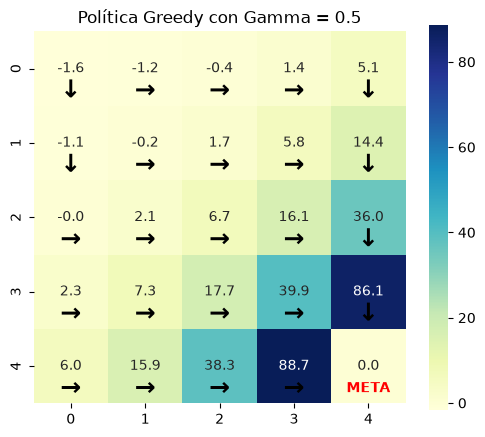


Análisis de Sensibilidad Gamma = 0.9


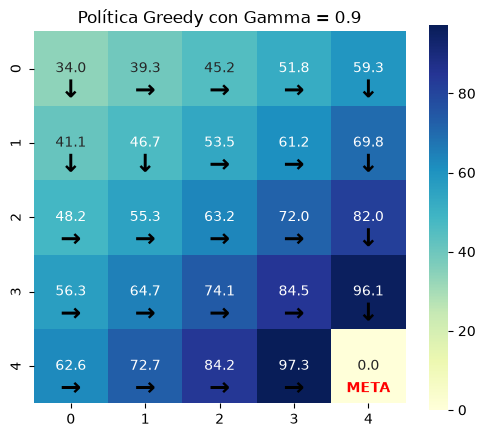

In [2]:
print("Análisis de Sensibilidad Gamma = 0.5")
V_g5, _ = evaluate_policy(policy_greedy, gamma=0.5)
pol_g5 = get_greedy_policy(V_g5, gamma=0.5)
plot_values_and_policy(V_g5, pol_g5, "Política Greedy con Gamma = 0.5")

print("\nAnálisis de Sensibilidad Gamma = 0.9")
V_g9, _ = evaluate_policy(policy_greedy, gamma=0.9)
pol_g9 = get_greedy_policy(V_g9, gamma=0.9)
plot_values_and_policy(V_g9, pol_g9, "Política Greedy con Gamma = 0.9")


**Discusión del Análisis de Sensibilidad:**
*   **Con $\gamma = 0.5$ (Miope):** Los valores caen drásticamente conforme nos alejamos de la meta. La recompensa terminal de $+100$ pierde su valor tan rápido (a la mitad en cada paso) que para el estado $(0,0)$ el valor es prácticamente nulo o negativo. La política resultante puede volverse subóptima a largas distancias porque el dron deja de "ver" el incentivo lejano de entregar.
*   **Con $\gamma = 0.9$:** Los valores son mejores y la política mantiene direcciones correctas, pero los estados lejanos siguen penalizados de más en comparación con el $\gamma = 0.99$ original. Esto confirma nuestra justificación inicial: un $\gamma$ muy cercano a $1.0$ es necesario en este problema logístico porque queremos maximizar la llegada al final de la ruta sin importar que tome un par de pasos extra debido al viento.

#### 3. Limitaciones del Modelo Implementado
*   **Aspectos no capturados:** El MDP actual en GridWorld 5x5 no captura el nivel de batería real, el peso del paquete, el tráfico aéreo (otros drones) ni la elevación (3D). Es una proyección puramente 2D idealizada.
*   **Extensiones necesarias:** Para que el modelo sea operacionalmente útil, se debe extender el espacio de estados a 3D $(x, y, z)$, incluir dinámicas de batería continuas reales y modelar ráfagas de viento no como simples probabilidades estáticas, sino dependientes del clima en tiempo real (POMDP u observaciones continuas de clima).

#### 4. Recomendación Concreta a Gerencia
*   **¿Es suficiente como base?** El MDP diseñado es una excelente **prueba de concepto conceptual**, pero **NO es suficiente** en su estado actual para construir un sistema de RL real para producción. Proporciona la base matemática correcta, pero le falta la dimensionalidad real del mundo físico.
*   **Próximos pasos:** Se recomienda encarecidamente **no proceder con la implementación completa en drones reales** todavía. El siguiente paso debe ser construir o adquirir un **simulador físico de alta fidelidad** (ej. en Unity o un entorno ROS) que permita simular físicas de vuelo, consumo de batería real y ráfagas continuas, para entrenar algoritmos de Deep RL (como PPO) en un entorno seguro antes de hacer pruebas de hardware.